# Recursive Bubble Sort Performance Analysis

This notebook implements recursive bubble sort and measures its execution time, comparisons, and swaps for sorted, random, and reverse-sorted inputs.

Recursive bubble sort has best-case time complexity **O(n)** when the input is already sorted, average- and worst-case time complexity **O(n^2)**, and **O(n)** auxiliary stack space because one recursive call is made for each pass.

In [1]:
import csv
from random import Random
from time import perf_counter

import matplotlib.pyplot as plt

## Recursive Bubble Sort

Each call performs one bubble-sort pass over the current unsorted prefix. The largest remaining value moves to the end of that prefix, and the next recursive call handles one fewer element.

In [2]:
def recursive_bubble_sort(values, end=None):
    """Sort values in place recursively and return (comparisons, swaps)."""
    if end is None:
        end = len(values) - 1

    if end <= 0:
        return 0, 0

    comparisons = 0
    swaps = 0
    swapped = False

    for index in range(end):
        comparisons += 1
        if values[index] > values[index + 1]:
            values[index], values[index + 1] = values[index + 1], values[index]
            swaps += 1
            swapped = True

    if not swapped:
        return comparisons, swaps

    remaining_comparisons, remaining_swaps = recursive_bubble_sort(values, end - 1)
    return (
        comparisons + remaining_comparisons,
        swaps + remaining_swaps,
    )

In [3]:
def measure(data):
    """Return elapsed seconds and operation counts for one sort."""
    values = data.copy()
    start = perf_counter()
    operations = recursive_bubble_sort(values)
    elapsed = perf_counter() - start

    if values != sorted(data):
        raise RuntimeError("recursive_bubble_sort failed to sort the data")

    return elapsed, operations


def build_input(size, case, random_generator):
    """Create one input of the requested size and case."""
    if case == "sorted":
        return list(range(size))
    if case == "reverse":
        return list(range(size, 0, -1))
    return [random_generator.randint(0, size * 10) for _ in range(size)]

In [9]:
def analyze(
    sizes=(100, 300, 500, 800),
    repetitions=3,
    csv_filename="recursive_bubble_sort_results.csv",
    graph_filename="recursive_bubble_sort_performance.png",
):
    """Run the experiment, print results, and create CSV and graph files."""
    random_generator = Random(42)
    cases = ("sorted", "random", "reverse")
    results = []

    print(
        f"{'n':>6}  {'case':<8} {'time (ms)':>12} "
        f"{'comparisons':>14} {'swaps':>8}"
    )
    print("-" * 58)

    for size in sizes:
        for case in cases:
            data = build_input(size, case, random_generator)
            measurements = [measure(data) for _ in range(repetitions)]
            elapsed = sum(item[0] for item in measurements) / repetitions
            comparisons = sum(item[1][0] for item in measurements) / repetitions
            swaps = sum(item[1][1] for item in measurements) / repetitions

            result = {
                "input_size": size,
                "case": case,
                "time_sec": elapsed,
                "comparisons": comparisons,
                "swaps": swaps,
            }
            results.append(result)
            print(
                f"{size:>6}  {case:<8} {elapsed * 1000:>12.3f} "
                f"{comparisons:>14.0f} {swaps:>8.0f}"
            )

    save_results(results, csv_filename)
    plot_results(results, graph_filename)
    return results

In [5]:
def save_results(results, filename):
    """Save measured performance data as CSV."""
    with open(filename, "w", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=["input_size", "case", "time_sec", "comparisons", "swaps"],
        )
        writer.writeheader()
        writer.writerows(results)
    print(f"CSV results saved to {filename}")


def plot_results(results, filename):
    """Save runtime and comparison charts as one PNG."""
    cases = ("sorted", "random", "reverse")
    colors = {"sorted": "tab:green", "random": "tab:blue", "reverse": "tab:red"}
    sizes = sorted({result["input_size"] for result in results})

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    for case in cases:
        case_results = [result for result in results if result["case"] == case]
        times = [result["time_sec"] * 1000 for result in case_results]
        comparisons = [result["comparisons"] for result in case_results]

        axes[0].plot(sizes, times, marker="o", color=colors[case], label=case.title())
        axes[1].plot(sizes, comparisons, marker="o", color=colors[case], label=case.title())

    axes[0].set_title("Recursive Bubble Sort Runtime")
    axes[0].set_xlabel("Input size (n)")
    axes[0].set_ylabel("Average time (ms)")
    axes[1].set_title("Recursive Bubble Sort Comparisons")
    axes[1].set_xlabel("Input size (n)")
    axes[1].set_ylabel("Average comparisons")

    for axis in axes:
        axis.grid(True, linestyle="--", alpha=0.6)
        axis.legend()

    figure.suptitle("Recursive Bubble Sort Performance Analysis")
    figure.tight_layout()
    figure.savefig(filename, dpi=150)
    plt.show()
    plt.close(figure)
    print(f"Graph saved to {filename}")

In [6]:
test_cases = [
    [],
    [1],
    [5, 1, 4, 2, 8],
    [3, 3, 2, 1, 2],
    list(range(20, -1, -1)),
]

for test_case in test_cases:
    expected = sorted(test_case)
    actual = test_case.copy()
    recursive_bubble_sort(actual)
    assert actual == expected

print("All correctness tests passed.")

All correctness tests passed.


     n  case        time (ms)    comparisons    swaps
----------------------------------------------------------
   100  sorted          0.022             99        0
   100  random          1.819           4740     2298
   100  reverse         1.294           4950     4950
   300  sorted          0.065            299        0
   300  random         13.799          44385    23263
   300  reverse        13.008          44850    44850
   500  sorted          0.063            499        0
   500  random         35.354         124084    59269
   500  reverse        36.440         124750   124750
   800  sorted          0.099            799        0
   800  random         82.736         317584   159343
   800  reverse        90.165         319600   319600
CSV results saved to recursive_bubble_sort_results.csv


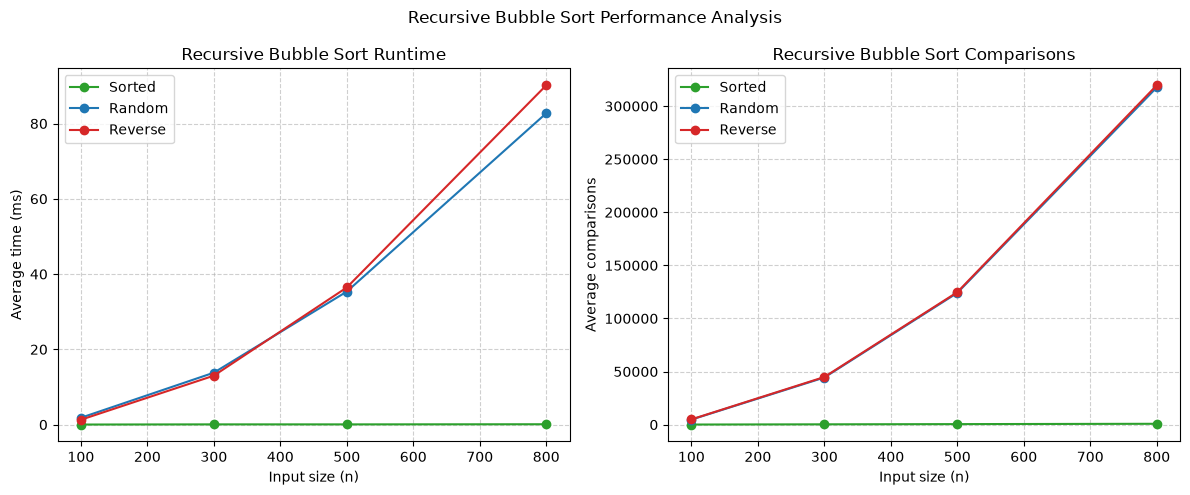

Graph saved to recursive_bubble_sort_performance.png


In [10]:
results = analyze()